<a href="https://colab.research.google.com/github/YellaSrinisha/MDS_Lab/blob/main/MDS_Week6%2C7%2C8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0           1             230.1                 37.8                     69.2   
1           2              44.5                 39.3                     45.1   
2           3              17.2                 45.9                     69.3   
3           4             151.5                 41.3                     58.5   
4           5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  


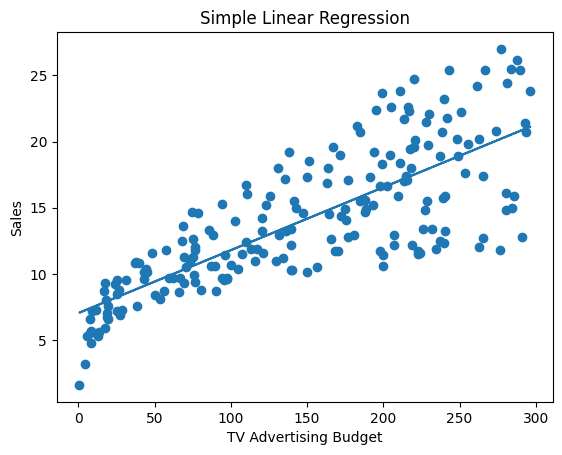

In [19]:
#linear regression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df = pd.read_csv('/content/Advertising Budget and Sales.csv')

print(df.head())

X = df[['TV Ad Budget ($)']]
y = df['Sales ($)']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('Simple Linear Regression')
plt.show()

In [18]:
#metrics,slope and intercept
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("MAE:", mean_absolute_error(y, y_pred))
print("MSE:", mean_squared_error(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred) ** 0.5)
print("R2 Score:", r2_score(y, y_pred))

Slope: 0.04753664043301975
Intercept: 7.032593549127695
MAE: 2.549806038927486
MSE: 10.512652915656757
RMSE: 3.2423221486546887
R2 Score: 0.611875050850071


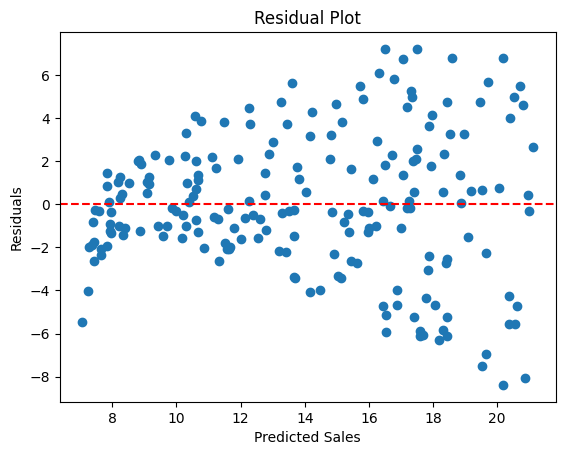

In [17]:
#residual plot
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

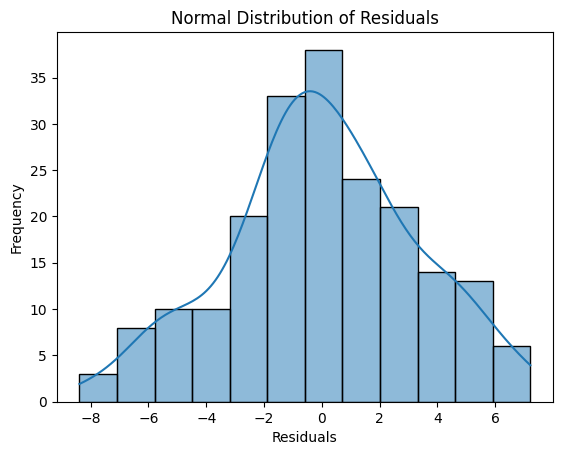

In [16]:
#normal distribution curve
import seaborn as sns

sns.histplot(residuals, kde=True)

plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Normal Distribution of Residuals')

plt.show()

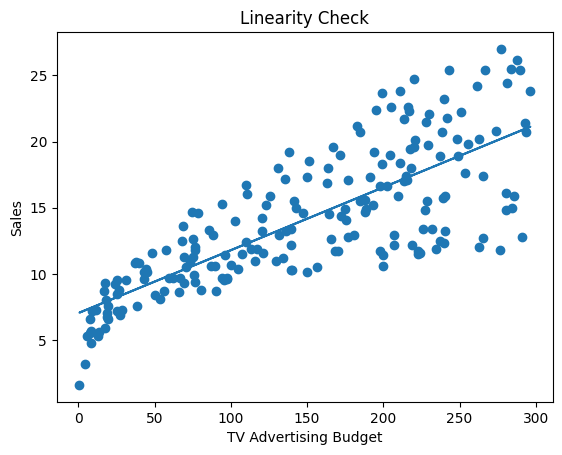

In [15]:
#linearity check
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('Linearity Check')

plt.show()

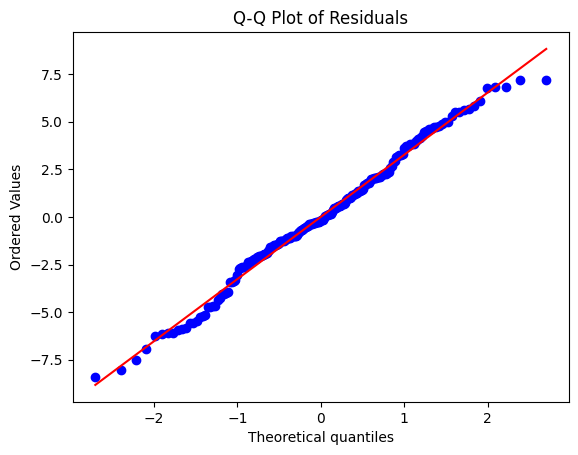

In [20]:
#Q-Q plot
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)

plt.title('Q-Q Plot of Residuals')

plt.show()

In [25]:
# Show observations with largest residuals
result = df.copy()
result['Predicted'] = y_pred
result['Residual'] = residuals

print(result.loc[result['Residual'].abs().sort_values(ascending=False).index].head(10))

     Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  \
178         179             276.7                  2.3   
35           36             290.7                  4.1   
25           26             262.9                  3.5   
55           56             198.9                 49.4   
128         129             220.3                 49.0   
131         132             265.2                  2.9   
147         148             243.2                 49.0   
175         176             276.9                 48.9   
58           59             210.8                 49.6   
165         166             234.5                  3.4   

     Newspaper Ad Budget ($)  Sales ($)  Predicted  Residual  
178                     23.7       11.8  20.185982 -8.385982  
35                       8.5       12.8  20.851495 -8.051495  
25                      19.5       12.0  19.529976 -7.529976  
55                      60.0       23.7  16.487631  7.212369  
128                      3.2       24.7  17.50

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("===== Multiple Linear Regression =====")

X = df[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
residuals = y - y_pred

print("\nInitial Model:")
print("R2 Score:", r2_score(y, y_pred))
print("RMSE:", mean_squared_error(y, y_pred) ** 0.5)

# Remove observations with large residuals
std = residuals.std()
mask = abs(residuals) <= 2 * std

X_new = X[mask]
y_new = y[mask]

print("\n===== Outlier Removal =====")
print("Original observations:", len(X))
print("Remaining observations:", len(X_new))
print("Removed observations:", len(X) - len(X_new))

# Refit model
model.fit(X_new, y_new)
y_pred_new = model.predict(X_new)

print("\n===== After Outlier Removal =====")
print("MAE:", mean_absolute_error(y_new, y_pred_new))
print("MSE:", mean_squared_error(y_new, y_pred_new))
print("RMSE:", mean_squared_error(y_new, y_pred_new) ** 0.5)
print("R2 Score:", r2_score(y_new, y_pred_new))

===== Multiple Linear Regression =====

Initial Model:
R2 Score: 0.8972106381789522
RMSE: 1.6685701407225697

===== Outlier Removal =====
Original observations: 200
Remaining observations: 193
Removed observations: 7

===== After Outlier Removal =====
MAE: 1.0808564544147696
MSE: 1.895408689379454
RMSE: 1.37673842445813
R2 Score: 0.9277894549455922


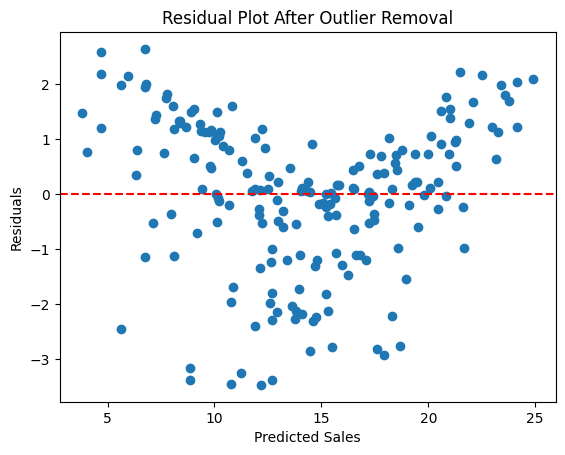

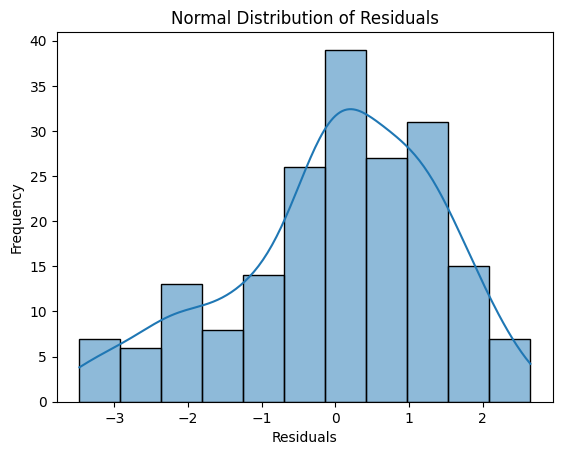

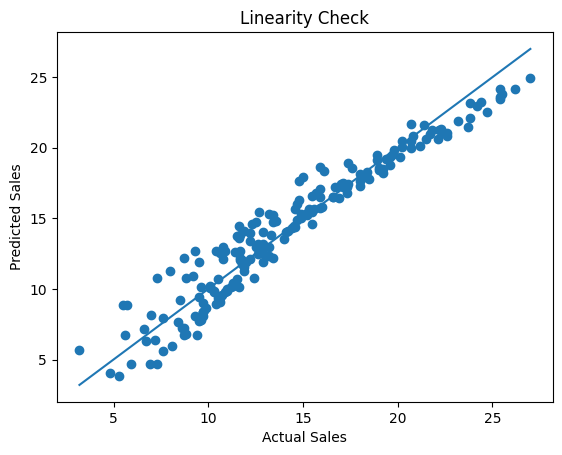

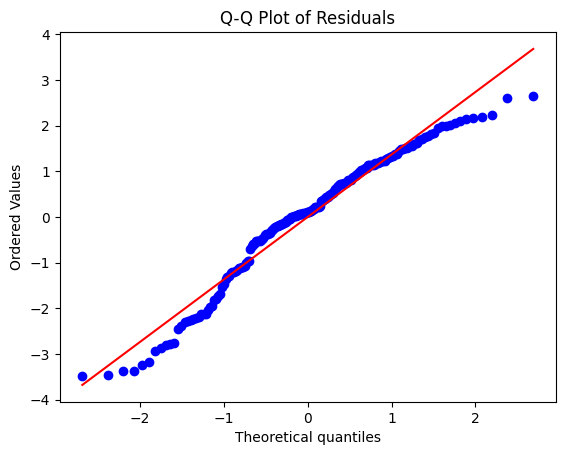

In [32]:
# 1. Residual Plot
plt.scatter(y_pred_new, residuals_new)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residual Plot After Outlier Removal')
plt.show()


# 2. Normal Distribution of Residuals
import seaborn as sns

sns.histplot(residuals_new, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Normal Distribution of Residuals')
plt.show()


# 3. Linearity Check
plt.scatter(y_new, y_pred_new)
plt.plot([y_new.min(), y_new.max()],
         [y_new.min(), y_new.max()])

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Linearity Check')
plt.show()


# 4. Q-Q Plot
import scipy.stats as stats

stats.probplot(residuals_new, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

Dataset Shape: (200, 7)

First 5 rows:
   House_ID  Area_sqft  Bedrooms  Bathrooms  Age_years  Distance_to_City_km  \
0      1001       1360         4          2          4                  6.0   
1      1002       1794         4          3         28                 22.1   
2      1003       1630         2          1          4                 19.2   
3      1004       1595         3          3          5                  2.1   
4      1005       2138         1          3         18                  7.4   

   Price_Lakhs  
0       109.43  
1       199.55  
2       125.13  
3       189.03  
4       212.60  

       LINEAR REGRESSION RESULTS
Slope     : 0.08247674702854477
Intercept : 27.778953142082173

Regression Equation:
Price = 0.0825 × Area + 27.7790

          MODEL METRICS
R² Score : 0.9081879014583163
MSE      : 459.1454885792143
RMSE     : 21.427680429276855

            RESIDUALS
Mean Residual    : 2.6858515411731786e-14
Minimum Residual: -64.68215989828269
Maximum Residual:

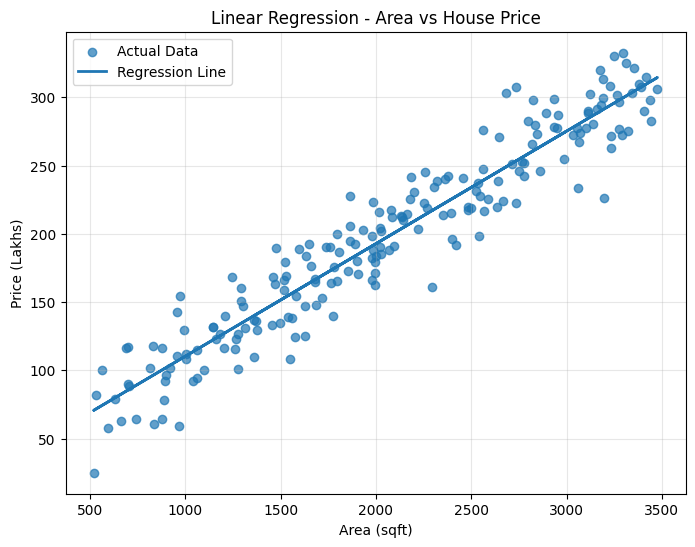

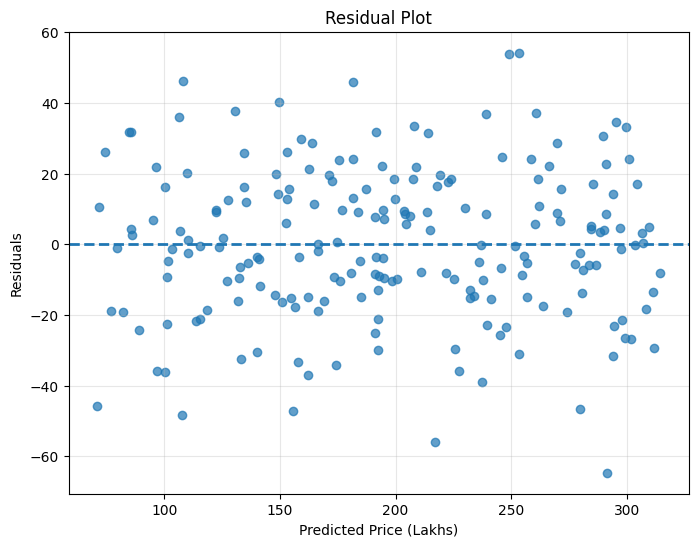

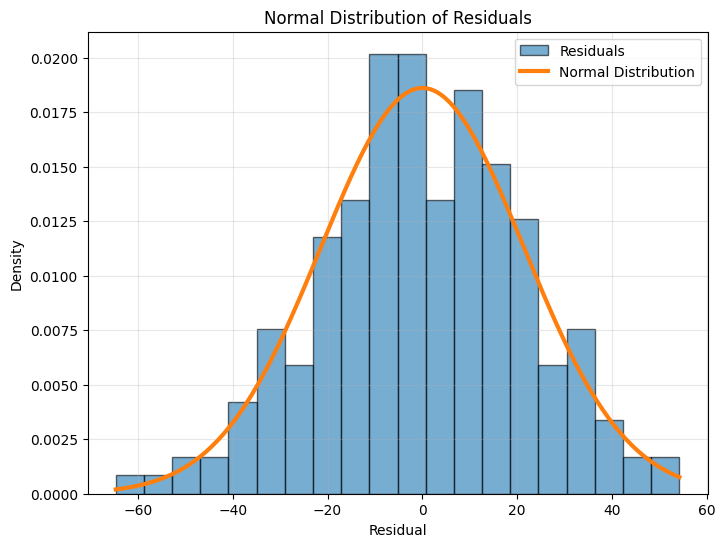

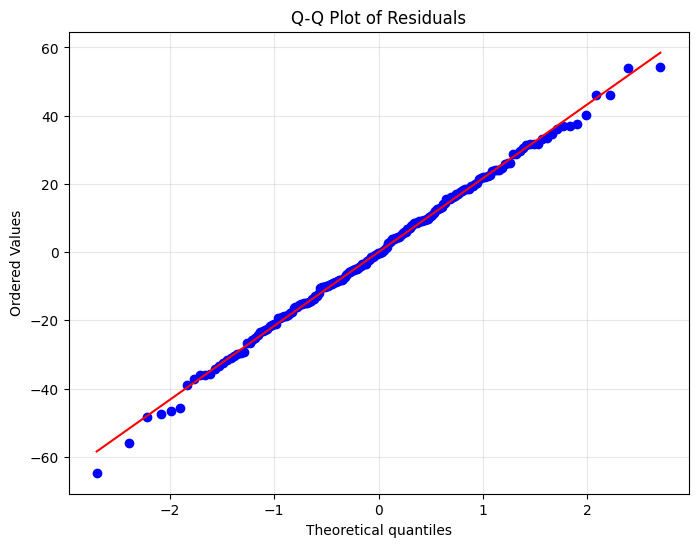

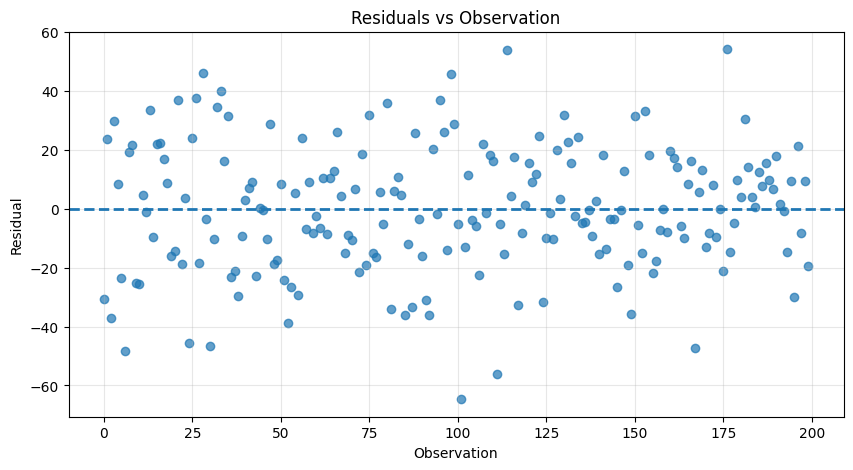


        SHAPIRO-WILK TEST
Test Statistic: 0.9972605365326552
p-value        : 0.9802435545611007


In [51]:
# ============================================
# HOUSE PRICE PREDICTION - LINEAR REGRESSION
# ============================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from scipy import stats


# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("House_Price_Prediction.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# ============================================
# 2. SELECT FEATURE AND TARGET
# ============================================

# Feature
X = df[["Area_sqft"]]

# Target
y = df["Price_Lakhs"]


# ============================================
# 3. CREATE LINEAR REGRESSION MODEL
# ============================================

model = LinearRegression()

# Fit model
model.fit(X, y)


# ============================================
# 4. PREDICTIONS
# ============================================

y_pred = model.predict(X)


# ============================================
# 5. SLOPE AND INTERCEPT
# ============================================

slope = model.coef_[0]
intercept = model.intercept_


# ============================================
# 6. MODEL EVALUATION
# ============================================

r2 = r2_score(y, y_pred)

mse = mean_squared_error(y, y_pred)

rmse = np.sqrt(mse)


# ============================================
# 7. CALCULATE RESIDUALS
# ============================================

residuals = y - y_pred


# ============================================
# 8. PRINT RESULTS
# ============================================

print("\n===================================")
print("       LINEAR REGRESSION RESULTS")
print("===================================")

print("Slope     :", slope)
print("Intercept :", intercept)

print("\nRegression Equation:")
print(f"Price = {slope:.4f} × Area + {intercept:.4f}")

print("\n===================================")
print("          MODEL METRICS")
print("===================================")

print("R² Score :", r2)
print("MSE      :", mse)
print("RMSE     :", rmse)

print("\n===================================")
print("            RESIDUALS")
print("===================================")

print("Mean Residual    :", residuals.mean())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())


# ============================================
# 9. REGRESSION LINE
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X,
    y,
    alpha=0.7,
    label="Actual Data"
)

plt.plot(
    X,
    y_pred,
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.title("Linear Regression - Area vs House Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================
# 10. RESIDUAL PLOT
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

# Zero residual line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 11. NORMAL DISTRIBUTION OF RESIDUALS
# ============================================

plt.figure(figsize=(8, 6))

# Histogram of residuals
plt.hist(
    residuals,
    bins=20,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Residuals"
)


# Calculate mean and standard deviation
mean = np.mean(residuals)
std = np.std(residuals)


# Create x values for bell curve
x = np.linspace(
    residuals.min(),
    residuals.max(),
    200
)


# Calculate normal distribution
bell_curve = stats.norm.pdf(
    x,
    mean,
    std
)


# Plot bell curve
plt.plot(
    x,
    bell_curve,
    linewidth=3,
    label="Normal Distribution"
)


plt.xlabel("Residual")
plt.ylabel("Density")

plt.title("Normal Distribution of Residuals")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 12. Q-Q PLOT
# ============================================

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 13. RESIDUALS VS OBSERVATION
# ============================================

plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(residuals)),
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observation")
plt.ylabel("Residual")

plt.title("Residuals vs Observation")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 14. NORMALITY TEST
# ============================================

stat, p_value = stats.shapiro(residuals)

print("\n===================================")
print("        SHAPIRO-WILK TEST")
print("===================================")

print("Test Statistic:", stat)
print("p-value        :", p_value)


      IMPROVED LINEAR REGRESSION

Intercept: 8.083335397001974

Coefficients:
Area_sqft                : 0.083591
Bedrooms                 : 5.694581
Bathrooms                : 4.580312
Age_years                : -0.542788
Distance_to_City_km      : 0.055451

             MODEL METRICS
Training R² : 0.9251
Testing R²  : 0.9278
MSE         : 276.4629
RMSE        : 16.6272

Residual Mean : -0.7589900010875319
Residual Min  : -47.853514327196706
Residual Max  : 38.09505340144406


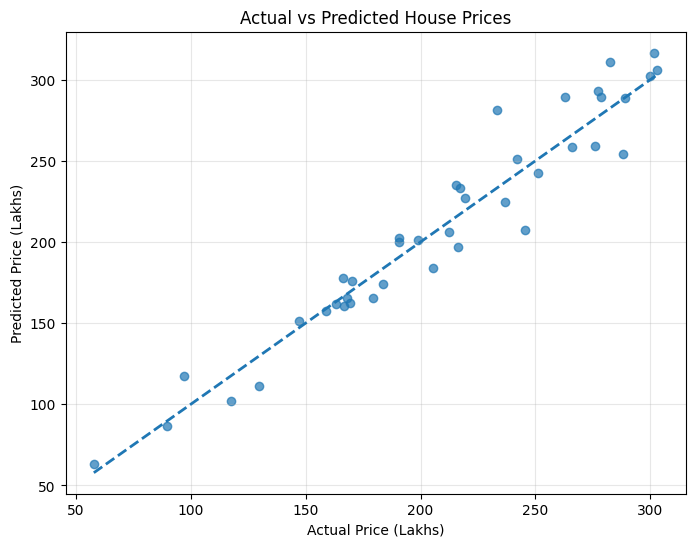

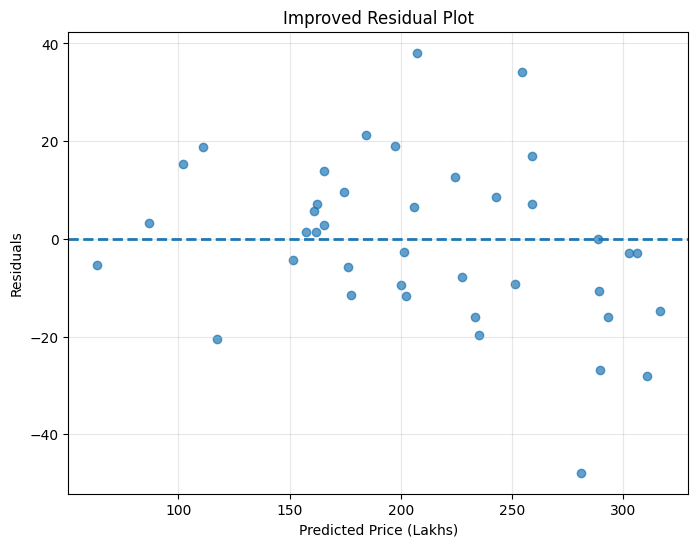

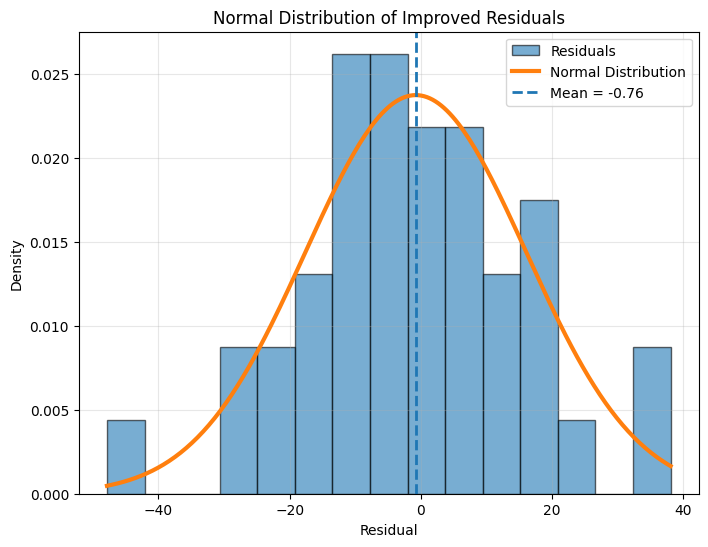

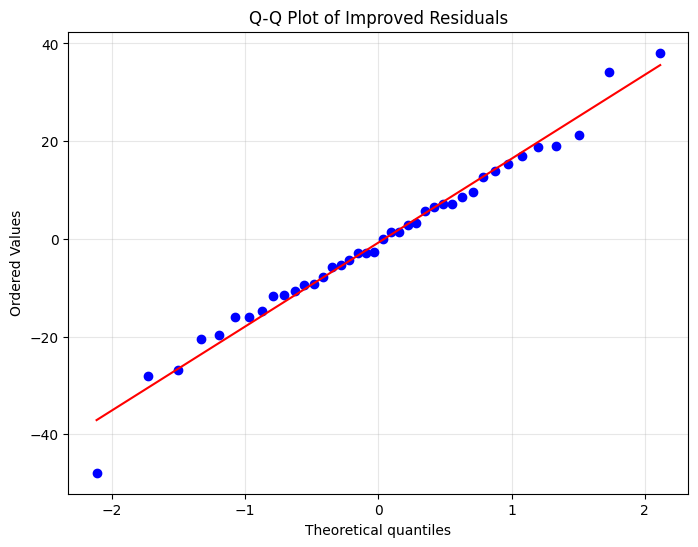

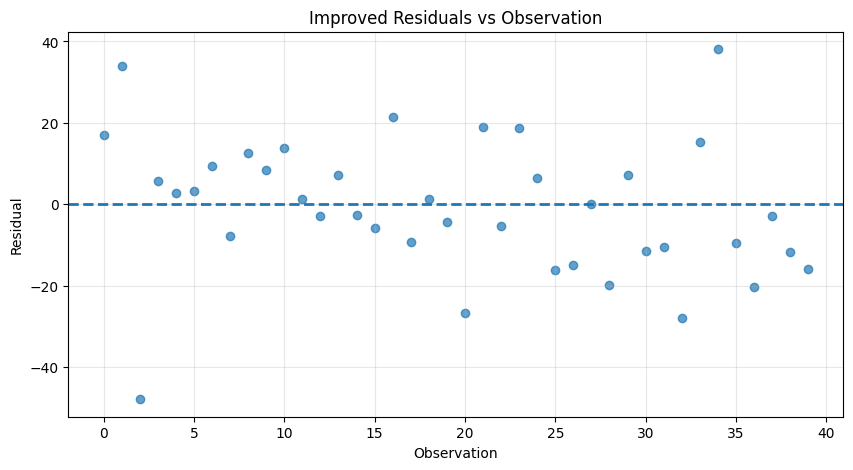

In [53]:
# ============================================
# IMPROVED MODEL - MULTIPLE LINEAR REGRESSION
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

import numpy as np
import matplotlib.pyplot as plt


# --------------------------------------------
# 1. Select multiple features
# --------------------------------------------

features = [
    "Area_sqft",
    "Bedrooms",
    "Bathrooms",
    "Age_years",
    "Distance_to_City_km"
]

X = df[features]
y = df["Price_Lakhs"]


# --------------------------------------------
# 2. Split data
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# --------------------------------------------
# 3. Create improved model
# --------------------------------------------

model_improved = LinearRegression()

model_improved.fit(X_train, y_train)


# --------------------------------------------
# 4. Predictions
# --------------------------------------------

y_train_pred = model_improved.predict(X_train)
y_test_pred = model_improved.predict(X_test)


# --------------------------------------------
# 5. Calculate residuals
# --------------------------------------------

residuals = y_test - y_test_pred


# --------------------------------------------
# 6. Calculate metrics
# --------------------------------------------

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)


# --------------------------------------------
# 7. Print coefficients
# --------------------------------------------

print("\n======================================")
print("      IMPROVED LINEAR REGRESSION")
print("======================================")

print("\nIntercept:", model_improved.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    features,
    model_improved.coef_
):
    print(f"{feature:25s}: {coefficient:.6f}")


# --------------------------------------------
# 8. Print performance
# --------------------------------------------

print("\n======================================")
print("             MODEL METRICS")
print("======================================")

print(f"Training R² : {r2_train:.4f}")
print(f"Testing R²  : {r2_test:.4f}")
print(f"MSE         : {mse:.4f}")
print(f"RMSE        : {rmse:.4f}")

print("\nResidual Mean :", residuals.mean())
print("Residual Min  :", residuals.min())
print("Residual Max  :", residuals.max())


# ============================================
# 9. Actual vs Predicted
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")

plt.title("Actual vs Predicted House Prices")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 10. IMPROVED RESIDUAL PLOT
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Price (Lakhs)")
plt.ylabel("Residuals")

plt.title("Improved Residual Plot")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 11. NORMAL DISTRIBUTION + BELL CURVE
# ============================================

plt.figure(figsize=(8, 6))

# Histogram
plt.hist(
    residuals,
    bins=15,
    density=True,
    alpha=0.6,
    edgecolor="black",
    label="Residuals"
)

# Mean and standard deviation
mean = residuals.mean()
std = residuals.std()

# X values for bell curve
x = np.linspace(
    residuals.min(),
    residuals.max(),
    200
)

# Normal distribution
bell_curve = stats.norm.pdf(
    x,
    mean,
    std
)

# Bell curve
plt.plot(
    x,
    bell_curve,
    linewidth=3,
    label="Normal Distribution"
)

plt.axvline(
    mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.2f}"
)

plt.xlabel("Residual")
plt.ylabel("Density")

plt.title("Normal Distribution of Improved Residuals")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 12. Q-Q PLOT
# ============================================

plt.figure(figsize=(8, 6))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Improved Residuals")

plt.grid(alpha=0.3)

plt.show()


# ============================================
# 13. RESIDUALS VS OBSERVATION
# ============================================

plt.figure(figsize=(10, 5))

plt.scatter(
    range(len(residuals)),
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Observation")
plt.ylabel("Residual")

plt.title("Improved Residuals vs Observation")

plt.grid(alpha=0.3)

plt.show()